# PEFT Methods — Building Blocks and Visualisations

Hands-on anatomy guide for six parameter-efficient adaptation strategies applied to a
pretrained **ViT-Small** (`WinKawaks/vit-small-patch16-224`, 22 M parameters, hidden dim 384).

Each section: (1) states the idea, (2) shows which parameters train, (3) visualises the mechanics.

| # | Method | What trains | Where it acts |
|---|---|---|---|
| 1 | Linear probe | classifier head | output / label space |
| 2 | BitFit | bias vectors only | small existing param subset |
| 3 | Visual prompt tuning | learnable prompt tokens | patch/token embedding space |
| 4 | LoRA | A and B matrices | weight space (low-rank delta) |
| 5 | Adapter | bottleneck residual | hidden-state path |
| 6 | Partial fine-tuning | last transformer block | checkpoint weights |

In [ ]:
import sys, os

if "google.colab" in sys.modules or "COLAB_GPU" in os.environ:
    if not os.path.exists("haicon_peft_co"):
        os.system("git clone https://github.com/trofimova/haicon_peft_co.git")
    os.chdir("haicon_peft_co")
    os.system("pip install -q transformers peft torchvision")
    os.system("pip install -q --upgrade torchao")

# make sure src/ is importable
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())


In [30]:
# !pip install -q torch torchvision transformers peft matplotlib pandas
import sys, copy
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from transformers import ViTModel

ROOT = Path.cwd()
if (ROOT / ".." / "src").exists():
    sys.path.insert(0, str((ROOT / "..").resolve()))
elif (ROOT / "src").exists():
    sys.path.insert(0, str(ROOT.resolve()))

from src.methods.linear_probe import LinearProbeModel
from src.methods.adapters import AdapterHeadClassifier
from src.methods.prompt_tuning import PromptTunedClassifier
from src.methods.lora import LoRAClassifier
from src.methods.bitfit import BitFitClassifier
from src.methods.partial_ft import PartialFineTuneClassifier
from src.training import count_trainable_parameters, freeze_module

torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [31]:
MODEL_NAME = "WinKawaks/vit-small-patch16-224"
N_CLASSES  = 10

class ViTBackbone(nn.Module):
    def __init__(self, model_name=MODEL_NAME):
        super().__init__()
        self.vit = ViTModel.from_pretrained(model_name)
        self.feature_dim = self.vit.config.hidden_size

    def forward(self, x):
        return self.vit(pixel_values=x).last_hidden_state[:, 0]  # CLS token

backbone = ViTBackbone().to(device)
freeze_module(backbone)

cfg   = backbone.vit.config
total = sum(p.numel() for p in backbone.parameters())
print(f"Model        : {MODEL_NAME}")
print(f"Hidden dim   : {cfg.hidden_size}")
print(f"Num layers   : {cfg.num_hidden_layers}")
print(f"Num heads    : {cfg.num_attention_heads}")
print(f"Total params : {total:,}")
D = backbone.feature_dim

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] ViTModel LOAD REPORT from: WinKawaks/vit-small-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model        : WinKawaks/vit-small-patch16-224
Hidden dim   : 384
Num layers   : 12
Num heads    : 6
Total params : 21,813,504


In [32]:
# Parameter breakdown by top-level component
rows = [{"component": name.split(".")[0], "params": p.numel()}
        for name, p in backbone.vit.named_parameters()]
summary = pd.DataFrame(rows).groupby("component")["params"].sum().sort_values(ascending=False)
print(summary.to_string())

component
encoder       21293568
embeddings      371328
pooler          147840
layernorm          768


---
## 1. Linear Probe

**Idea:** The pretrained backbone is frozen. Only a single linear layer (the classifier head)
is trained on the new task.

```
input → [frozen ViT] → CLS feature h ∈ ℝᴰ → [W, b  trainable] → logits
```

**When to use:** First baseline when you believe pretrained features are already
linearly separable for your task.

Trainable : 3,850 / 21,817,354  (0.018%)

  head.weight                         shape=[10, 384]  numel=3840
  head.bias                           shape=[10]  numel=10


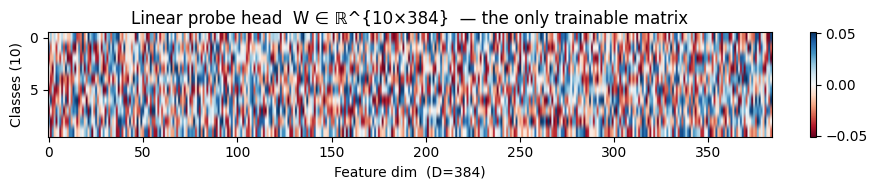

In [33]:
lp = LinearProbeModel(copy.deepcopy(backbone), D, N_CLASSES)

total_p = sum(p.numel() for p in lp.parameters())
train_p = count_trainable_parameters(lp)
print(f"Trainable : {train_p:,} / {total_p:,}  ({100*train_p/total_p:.3f}%)")
print()
for name, p in lp.named_parameters():
    if p.requires_grad:
        print(f"  {name:35s} shape={list(p.shape)}  numel={p.numel()}")

W = lp.head.weight.detach().cpu()      # [N_CLASSES, D]
fig, ax = plt.subplots(figsize=(9, 2))
v = W.abs().max().item()
im = ax.imshow(W.numpy(), cmap="RdBu", vmin=-v, vmax=v, aspect="auto")
plt.colorbar(im, ax=ax, fraction=0.015)
ax.set_xlabel(f"Feature dim  (D={W.shape[1]})")
ax.set_ylabel(f"Classes ({W.shape[0]})")
ax.set_title(f"Linear probe head  W ∈ ℝ^{{{W.shape[0]}×{W.shape[1]}}}  — the only trainable matrix")
plt.tight_layout()
plt.show()

---
## 2. BitFit

**Paper:** Zaken et al. 2021 — *"BitFit: Simple Parameter-efficient Fine-tuning for Transformer-based Masked Language-Models"*

**Idea:** Freeze every weight *matrix*; only let *bias vectors* and LayerNorm β terms accumulate gradients.

```
y = W x + b    →    W frozen,   b trainable
```

**Why it can work:** In a trained transformer, weight matrices encode the principal computation directions
(what to attend to, how to project). Biases and LayerNorm β shift and scale the resulting activations.
Fine-tuning biases redirects *where* the model focuses without rotating its learned feature space.

**What trains in each block** (ViT-Small, hidden dim 384):

| Parameter | Shape | Role |
|---|---|---|
| Q / K / V projection bias | (384,) | shifts attention logits |
| Attention output bias | (384,) | shifts attended value |
| FFN up-projection bias | (1536,) | shifts intermediate activations |
| FFN down-projection bias | (384,) | shifts block output |
| LayerNorm₁ β | (384,) | shifts normalised residual (pre-attn) |
| LayerNorm₂ β | (384,) | shifts normalised residual (pre-FFN) |

**Key result from the paper:** On most GLUE benchmarks BitFit matches or approaches full fine-tuning
while training < 0.1 % of parameters.

Trainable : 55,690 / 21,817,354  (0.255%)


/var/folders/sh/6l05yj_906v9_246m_pgtjzr0000gp/T/ipykernel_18938/4066749475.py:65: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("Set2", len(rep))


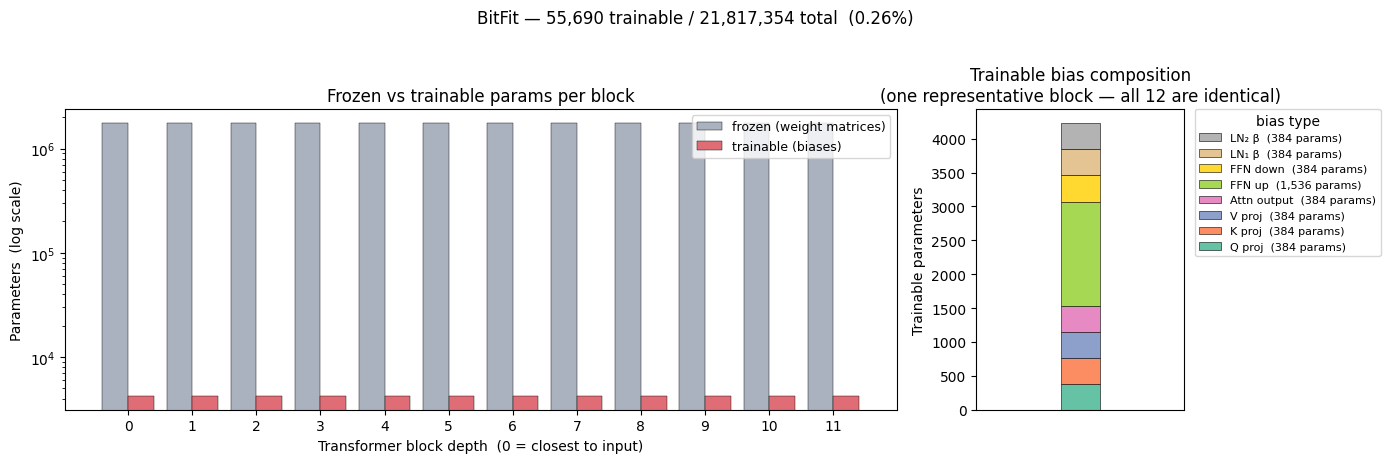

In [34]:
bf = BitFitClassifier(copy.deepcopy(backbone), D, N_CLASSES)

total_p = sum(p.numel() for p in bf.parameters())
train_p = count_trainable_parameters(bf)
print(f"Trainable : {train_p:,} / {total_p:,}  ({100*train_p/total_p:.3f}%)")

# ── Collect per-block statistics ──────────────────────────────────────────────
BIAS_TYPES = {
    "Q proj":         ".attention.attention.query.bias",
    "K proj":         ".attention.attention.key.bias",
    "V proj":         ".attention.attention.value.bias",
    "Attn output":    ".attention.output.dense.bias",
    "FFN up":         ".intermediate.dense.bias",
    "FFN down":       ".output.dense.bias",
    "LN\u2081 \u03b2": ".layernorm_before.bias",
    "LN\u2082 \u03b2": ".layernorm_after.bias",
}

block_stats    = {}   # {block_idx: {total, trainable}}
bias_breakdown = {}   # {block_idx: {bias_type: numel}}

for name, p in bf.backbone.named_parameters():
    if "encoder.layer" not in name:
        continue
    idx    = int(name.split("encoder.layer.")[1].split(".")[0])
    prefix = f"encoder.layer.{idx}"
    suffix = name[name.index(prefix) + len(prefix):]

    d = block_stats.setdefault(idx, {"total": 0, "trainable": 0})
    d["total"]     += p.numel()
    d["trainable"] += p.numel() if p.requires_grad else 0

    for btype, bsuffix in BIAS_TYPES.items():
        if suffix == bsuffix:
            bias_breakdown.setdefault(idx, {})[btype] = p.numel()
            break

df_blocks = pd.DataFrame(block_stats).T.sort_index()
df_blocks["frozen"] = df_blocks["total"] - df_blocks["trainable"]
df_bias   = pd.DataFrame(bias_breakdown).T.sort_index().fillna(0).astype(int)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5),
                         gridspec_kw={"width_ratios": [4, 1]})

# Left: grouped bars — frozen (grey) and trainable (red) side-by-side per block
x     = np.arange(len(df_blocks))
width = 0.4
axes[0].bar(x - width/2, df_blocks["frozen"],    width=width, color="#abb2bf",
            label="frozen (weight matrices)", edgecolor="black", linewidth=0.3)
axes[0].bar(x + width/2, df_blocks["trainable"], width=width, color="#e06c75",
            label="trainable (biases)", edgecolor="black", linewidth=0.3)
axes[0].set_yscale("log")
axes[0].set_xlabel("Transformer block depth  (0 = closest to input)")
axes[0].set_ylabel("Parameters  (log scale)")
axes[0].set_title("Frozen vs trainable params per block")
axes[0].set_xticks(x)
axes[0].set_xticklabels(df_blocks.index)
axes[0].legend(fontsize=9)

# Right: single stacked bar — trainable bias composition for one representative block
# (all blocks are structurally identical so one bar is sufficient)
rep = df_bias.iloc[0]
rep = rep[rep > 0]
cmap = plt.cm.get_cmap("Set2", len(rep))
colours = [cmap(i) for i in range(len(rep))]
bottom = 0
for colour, (btype, count) in zip(colours, rep.items()):
    axes[1].bar(0, count, bottom=bottom, width=0.15, color=colour,
                edgecolor="black", linewidth=0.4,
                label=f"{btype}  ({count:,} params)")
    bottom += count
axes[1].set_xlim(-0.4, 0.4)
axes[1].set_xticks([])
axes[1].set_ylabel("Trainable parameters")
axes[1].set_title("Trainable bias composition\n(one representative block — all 12 are identical)")
handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(handles[::-1], labels[::-1], fontsize=8, title="bias type",
               bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0)

plt.suptitle(
    f"BitFit — {train_p:,} trainable / {total_p:,} total  ({100*train_p/total_p:.2f}%)",
    fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

---
## 3. Visual Prompt Tuning — Token Space (VPT, Jia et al. 2022)

**Idea:** Keep the image and all ViT weights frozen. Instead, prepend k learnable
vectors directly into the **token sequence** inside the ViT, between the CLS token
and the first patch token.

```
Image  →  patch embed  →  [CLS | p₁ … pₖ | patch₁ … patchN]  →  frozen encoder  →  head
                                ↑ only these k vectors are trained
```

The frozen encoder attends to the prompt tokens alongside the patch tokens at every
layer — the prompts act as trainable "context" that steers attention without
touching any weight matrix.

**Shallow vs deep VPT:**
- **Shallow** (our implementation): prompts inserted once, before layer 0.
- **Deep**: fresh prompt tokens inserted at every transformer layer.

**What trains:** k vectors of size D (the embedding dimension) plus the head.

Trainable : 7,690 / 21,821,194  (0.0352%)
Prompt tokens  : 10  ×  D=384  =  3,840 params  (+ head)
Sample class : automobile

Original sequence  : 1 CLS + 196 patches = 197 tokens
Prompted sequence  : 1 CLS + 10 prompts + 196 patches = 207 tokens


/Users/e230-admin/miniconda3/envs/peft_haicon/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


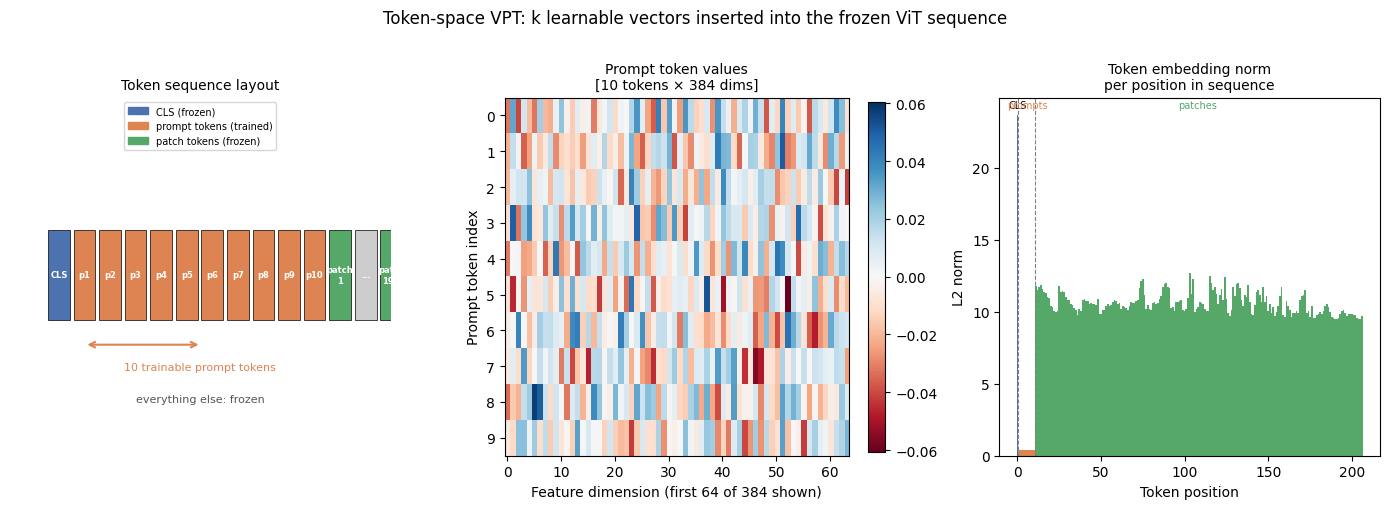

In [35]:
NUM_TOKENS = 10

vpt = PromptTunedClassifier(copy.deepcopy(backbone), D, N_CLASSES,
                             num_prompt_tokens=NUM_TOKENS).to(device)

total_p = sum(p.numel() for p in vpt.parameters())
train_p = count_trainable_parameters(vpt)
print(f"Trainable : {train_p:,} / {total_p:,}  ({100*train_p/total_p:.4f}%)")
print(f"Prompt tokens  : {NUM_TOKENS}  ×  D={D}  =  {NUM_TOKENS*D:,} params  (+ head)")

# ── Load one CIFAR-10 sample ──────────────────────────────────────────────────
from torchvision import datasets, transforms

cifar_tf = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor()])
cifar = datasets.CIFAR10(root="/tmp/cifar10", train=False, download=True, transform=cifar_tf)
CIFAR_CLASSES = ["airplane","automobile","bird","cat","deer",
                 "dog","frog","horse","ship","truck"]
img, label = cifar[6]
print(f"Sample class : {CIFAR_CLASSES[label]}")

# ── Inspect the token sequence ────────────────────────────────────────────────
with torch.no_grad():
    vit = vpt.backbone.vit
    emb_orig     = vit.embeddings(img.unsqueeze(0).to(device))          # [1, 1+N, D]
    emb_prompted = vpt.prompt.insert(emb_orig)                          # [1, 1+k+N, D]

n_patches = emb_orig.shape[1] - 1   # N
print(f"\nOriginal sequence  : 1 CLS + {n_patches} patches = {emb_orig.shape[1]} tokens")
print(f"Prompted sequence  : 1 CLS + {NUM_TOKENS} prompts + {n_patches} patches = {emb_prompted.shape[1]} tokens")

# ── Visualise ─────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 5))
fig.suptitle("Token-space VPT: k learnable vectors inserted into the frozen ViT sequence",
             fontsize=12, y=1.01)

# ── Panel 1: sequence diagram ─────────────────────────────────────────────────
ax1 = fig.add_subplot(1, 3, 1)
ax1.set_xlim(0, 1); ax1.set_ylim(0, 1); ax1.axis("off")
ax1.set_title("Token sequence layout", fontsize=10)

seq = (
    [("CLS", "#4c72b0")] +
    [(f"p{i+1}", "#dd8452") for i in range(NUM_TOKENS)] +
    [("patch\n1", "#55a868"), ("...", "#cccccc"), (f"patch\n{n_patches}", "#55a868")]
)
n = len(seq)
bw, bh, gap = 0.8/n, 0.25, 0.01
for i, (lbl, col) in enumerate(seq):
    x0 = 0.1 + i * (bw + gap)
    rect = plt.Rectangle((x0, 0.38), bw, bh, color=col, ec="black", lw=0.5)
    ax1.add_patch(rect)
    ax1.text(x0 + bw/2, 0.38 + bh/2, lbl, ha="center", va="center",
             fontsize=6, color="white", fontweight="bold")

ax1.annotate("", xy=(0.1 + (bw+gap) + bw/2, 0.31),
             xytext=(0.1 + (1+NUM_TOKENS/2)*(bw+gap), 0.31),
             arrowprops=dict(arrowstyle="<->", color="#dd8452", lw=1.5))
ax1.text(0.5, 0.24, f"{NUM_TOKENS} trainable prompt tokens", ha="center",
         fontsize=8, color="#dd8452")
ax1.text(0.5, 0.15, "everything else: frozen", ha="center",
         fontsize=8, color="#555")

handles = [mpatches.Patch(color="#4c72b0", label="CLS (frozen)"),
           mpatches.Patch(color="#dd8452", label="prompt tokens (trained)"),
           mpatches.Patch(color="#55a868", label="patch tokens (frozen)")]
ax1.legend(handles=handles, loc="upper center", fontsize=7, frameon=True)

# ── Panel 2: prompt token heatmap [k, D_shown] ───────────────────────────────
ax2 = fig.add_subplot(1, 3, 2)
D_show = 64
tokens_np = vpt.prompt.tokens.detach().cpu()[0, :, :D_show].numpy()  # [k, D_show]
v = max(abs(tokens_np).max(), 1e-6)
im2 = ax2.imshow(tokens_np, cmap="RdBu", vmin=-v, vmax=v, aspect="auto")
plt.colorbar(im2, ax=ax2, fraction=0.046)
ax2.set_xlabel(f"Feature dimension (first {D_show} of {D} shown)")
ax2.set_ylabel("Prompt token index")
ax2.set_yticks(range(NUM_TOKENS))
ax2.set_title(f"Prompt token values\n[{NUM_TOKENS} tokens × {D} dims]", fontsize=10)

# ── Panel 3: L2 norm per position in prompted sequence ───────────────────────
ax3 = fig.add_subplot(1, 3, 3)
norms = emb_prompted[0].norm(dim=-1).cpu().numpy()   # [1+k+N]
colours_bar = (
    ["#4c72b0"] +                          # CLS
    ["#dd8452"] * NUM_TOKENS +             # prompts
    ["#55a868"] * n_patches                # patches
)
ax3.bar(range(len(norms)), norms, color=colours_bar, width=1.0, edgecolor="none")
ax3.set_xlabel("Token position")
ax3.set_ylabel("L2 norm")
ax3.set_title("Token embedding norm\nper position in sequence", fontsize=10)
ax3.axvline(0.5,              color="gray", linewidth=0.8, linestyle="--")
ax3.axvline(NUM_TOKENS + 0.5, color="gray", linewidth=0.8, linestyle="--")
ax3.text(0,              max(norms)*1.02, "CLS",     fontsize=7, ha="center")
ax3.text(NUM_TOKENS/2+1, max(norms)*1.02, "prompts", fontsize=7, ha="center", color="#dd8452")
ax3.text(NUM_TOKENS + n_patches/2, max(norms)*1.02, "patches", fontsize=7,
         ha="center", color="#55a868")

plt.tight_layout()
plt.show()

---
## 4. LoRA — Low-Rank Adaptation

**Idea:** Decompose the weight update as a product of two small matrices:

```
W_eff = W₀ + ΔW = W₀ + B · A
```

- A ∈ ℝ^{r×d_in},  B ∈ ℝ^{d_out×r},  rank r ≪ d
- A initialised from Gaussian;  B initialised to **zero** → ΔW = 0 at the start
- W₀ is never updated; only A and B accumulate gradients

**Parameter saving:**  r·(d_in + d_out)  vs  d_in·d_out  for a full update.

Applied via the **PEFT library** to the `query` and `value` projections in every
attention layer.

Trainable : 151,306 / 21,964,810  (0.69%)
Loss after 30 steps: 0.0025

First LoRA layer : backbone.base_model.model.vit.encoder.layer.11.attention.attention.value
W₀ shape : (384, 384)   (147,456 params — frozen)
A  shape : (8, 384)
B  shape : (384, 8)   combined 6,144 trainable params
Rank of ΔW=BA : 8  (equals r=8 by construction)
Compression   : 147,456 → 6,144  (4.2% of original)


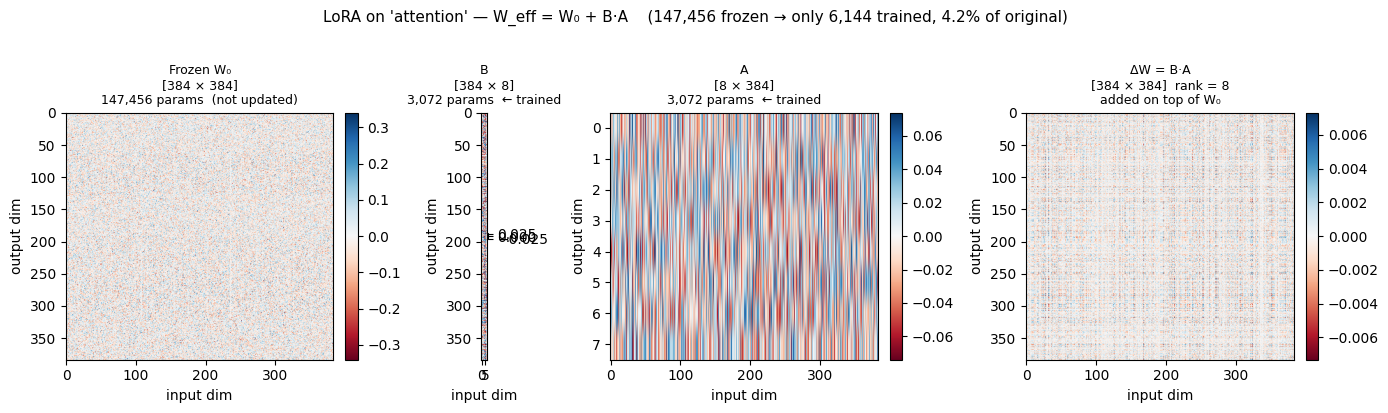

In [ ]:
RANK = 8
lora_m = LoRAClassifier(copy.deepcopy(backbone), D, N_CLASSES,
                        target_modules=["query", "value"], rank=RANK)

total_p = sum(p.numel() for p in lora_m.parameters())
train_p = count_trainable_parameters(lora_m)
print(f"Trainable : {train_p:,} / {total_p:,}  ({100*train_p/total_p:.2f}%)")

def find_last_lora(model):
    result = None
    for name, module in model.named_modules():
        if hasattr(module, "lora_A") and module.lora_A:
            key = next(iter(module.lora_A))
            result = (name,
                      module.weight.detach().cpu(),
                      module.lora_A[key].weight.detach().cpu(),
                      module.lora_B[key].weight.detach().cpu())
    if result is None:
        raise RuntimeError("No LoRA layer found")
    return result

# ── A few gradient steps to get meaningful matrices ───────────────────────────
# PEFT initialises B = 0  →  ΔW = B·A = 0 at the start.
# Running a handful of steps makes B non-zero so we can visualise the adaptation.
torch.manual_seed(0)
x_syn = torch.randn(8, 3, 224, 224, device=device)
y_syn = torch.randint(0, N_CLASSES, (8,), device=device)

lora_m.to(device).train()
opt = torch.optim.AdamW([p for p in lora_m.parameters() if p.requires_grad], lr=1e-3)
for step in range(2):
    opt.zero_grad()
    loss = F.cross_entropy(lora_m(x_syn), y_syn)
    loss.backward()
    opt.step()
lora_m.eval()
print(f"Loss after 30 steps: {loss.item():.4f}")

name, W0, A, B = find_last_lora(lora_m)
dW = B @ A
print(f"\nFirst LoRA layer : {name}")
print(f"W₀ shape : {tuple(W0.shape)}   ({W0.numel():,} params — frozen)")
print(f"A  shape : {tuple(A.shape)}")
print(f"B  shape : {tuple(B.shape)}   combined {A.numel()+B.numel():,} trainable params")
print(f"Rank of ΔW=BA : {int(torch.linalg.matrix_rank(dW))}  (equals r={RANK} by construction)")
print(f"Compression   : {W0.numel():,} → {A.numel()+B.numel():,}  ({100*(A.numel()+B.numel())/W0.numel():.1f}% of original)")

# ── Visualise W0, B, A, ΔW with proportional subplot widths ──────────────────
r, d_in, d_out = A.shape[0], A.shape[1], B.shape[0]

fig, axes = plt.subplots(1, 4, figsize=(14, 4),
                         gridspec_kw={"width_ratios": [d_out, r, d_in, d_out]})

for ax, mat, title in [
    (axes[0], W0,  f"Frozen W₀\n[{d_out} × {d_in}]\n{W0.numel():,} params  (not updated)"),
    (axes[1], B,   f"B\n[{d_out} × {r}]\n{B.numel():,} params  ← trained"),
    (axes[2], A,   f"A\n[{r} × {d_in}]\n{A.numel():,} params  ← trained"),
    (axes[3], dW,  f"ΔW = B·A\n[{d_out} × {d_in}]  rank = {int(torch.linalg.matrix_rank(dW))}\nadded on top of W₀"),
]:
    v = max(mat.abs().max().item(), 1e-8)
    im = ax.imshow(mat.numpy(), cmap="RdBu", vmin=-v, vmax=v, aspect="auto")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("input dim")
    ax.set_ylabel("output dim")

plt.suptitle(
    f"LoRA on '{name.split('.')[-3]}' — W_eff = W₀ + B·A    "
    f"({W0.numel():,} frozen → only {A.numel()+B.numel():,} trained, "
    f"{100*(A.numel()+B.numel())/W0.numel():.1f}% of original)",
    fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

---
## 5. Adapter

**Idea:** After the frozen backbone, insert a small trainable bottleneck module:

```
h  →  down(h)  →  GELU  →  up(·)  →  h + residual   →  head
```

- down: ℝᴰ → ℝᵏ  (compress),   up: ℝᵏ → ℝᴰ  (expand),   k ≪ D
- The residual connection means the adapter starts as a near-identity at init.

**Implementation note:** `AdapterHeadClassifier` places the adapter on the pooled
CLS token *after* the full backbone — pedagogically clean. Standard Houlsby adapters
are inserted *inside* each transformer block (after attention and FFN sub-layers).

In [ ]:
K = 32
ad = AdapterHeadClassifier(copy.deepcopy(backbone), D, N_CLASSES, bottleneck_dim=K)

total_p = sum(p.numel() for p in ad.parameters())
train_p = count_trainable_parameters(ad)
print(f"Trainable : {train_p:,} / {total_p:,}  ({100*train_p/total_p:.4f}%)")
print(f"Bottleneck: {D} → {K} → {D}  (down: {D*K:,} params,  up: {K*D:,} params)")

W_down = ad.adapter.down.weight.detach().cpu()   # [K, D]
W_up   = ad.adapter.up.weight.detach().cpu()     # [D, K]

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
for ax, W, title in zip(
    axes,
    [W_down, W_up],
    [f"Down projection  [{K} × {D}]  compress D→k",
     f"Up projection  [{D} × {K}]  expand k→D"]):
    v = W.abs().max().item()
    im = ax.imshow(W.numpy(), cmap="RdBu", vmin=-v, vmax=v, aspect="auto")
    plt.colorbar(im, ax=ax, fraction=0.02)
    ax.set_title(title)
    ax.set_xlabel("input dim")
    ax.set_ylabel("output dim")
plt.suptitle(f"Adapter bottleneck (k={K}, D={D})", y=1.01)
plt.tight_layout()
plt.show()

# Verify near-identity at init
h = torch.randn(1, D)
with torch.no_grad():
    h_out = ad.adapter(h)
print(f"\nMax residual change at init: {(h_out - h).abs().max().item():.5f}  (near zero by design)")


---
## 6. Partial Fine-tuning

**Idea:** Freeze all layers except the last N transformer blocks and the head.
No new modules — just standard gradient updates on selected pretrained weights.

```
[frozen blocks 0 … L-2]  →  [trainable block L-1]  →  CLS  →  [trainable head]
```

**Tradeoff:** More expressive than LoRA at the same block, but creates a full-size
task-specific checkpoint (no sharing with the base model).

In [ ]:
configs = [
    ("Last 4 layers",  list(range(8, 12))),
    ("Last 8 layers",  list(range(4, 12))),
    ("All 12 layers",  list(range(0, 12))),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5), sharey=True)

for ax, (title, unfreeze_idx) in zip(axes, configs):
    bb = copy.deepcopy(backbone)
    blocks = list(bb.vit.encoder.layer)
    modules = [blocks[i] for i in unfreeze_idx]
    model = PartialFineTuneClassifier(bb, D, N_CLASSES, modules_to_unfreeze=modules)

    total_p = sum(p.numel() for p in model.parameters())
    train_p = count_trainable_parameters(model)

    block_data = {}
    for name, p in model.backbone.named_parameters():
        if "encoder.layer" not in name:
            continue
        idx = int(name.split("encoder.layer.")[1].split(".")[0])
        d = block_data.setdefault(idx, {"total": 0, "trainable": 0})
        d["total"]     += p.numel()
        d["trainable"] += p.numel() if p.requires_grad else 0

    df = pd.DataFrame(block_data).T.sort_index()
    df["frozen"] = df["total"] - df["trainable"]

    ax.bar(df.index, df["frozen"],    color="#abb2bf", label="frozen")
    ax.bar(df.index, df["trainable"], color="#e06c75", label="trainable",
           bottom=df["frozen"])
    ax.set_title(f"{title}\n{train_p:,} / {total_p:,}  ({100*train_p/total_p:.1f}%)",
                 fontsize=10)
    ax.set_xlabel("Block index")
    ax.set_xticks(df.index)
    ax.tick_params(axis="x", labelsize=8)

axes[0].set_ylabel("Parameters")
axes[0].legend(fontsize=8)
fig.suptitle("Partial fine-tuning: how many blocks to unfreeze?", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


---
## 7. Summary — Parameter Efficiency and Gradient Flow

In [ ]:
variants = {
    "linear_probe" : LinearProbeModel(copy.deepcopy(backbone), D, N_CLASSES),
    "bitfit"       : BitFitClassifier(copy.deepcopy(backbone), D, N_CLASSES),
    "visual_prompt": PromptTunedClassifier(copy.deepcopy(backbone), D, N_CLASSES, num_prompt_tokens=32),
    "lora"         : LoRAClassifier(copy.deepcopy(backbone), D, N_CLASSES,
                                    target_modules=["query", "value"], rank=8),
    "adapter"      : AdapterHeadClassifier(copy.deepcopy(backbone), D, N_CLASSES, bottleneck_dim=32),
}

total_p = sum(p.numel() for p in backbone.parameters())
rows = [{"method": n, "trainable": count_trainable_parameters(m),
         "% of backbone": f"{100*count_trainable_parameters(m)/total_p:.3f}%"}
        for n, m in variants.items()]
df_s = pd.DataFrame(rows).set_index("method")
print(df_s.to_string())

train_counts = df_s["trainable"]
colors = ["#4c72b0", "#dd8452", "#55a868", "#c44e52", "#8172b2"]

fig, ax = plt.subplots(figsize=(8, 3.2))
bars = ax.barh(train_counts.index, train_counts.values, color=colors)
ax.set_xlabel("Trainable parameters")
ax.set_title("Trainable parameter count per PEFT method")
ax.set_xlim(0, train_counts.max() * 1.18)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
for bar, val in zip(bars, train_counts.values):
    ax.text(val + train_counts.max() * 0.01, bar.get_y() + bar.get_height()/2,
            f"{val:,}", va="center", fontsize=8)
plt.tight_layout()
plt.show()


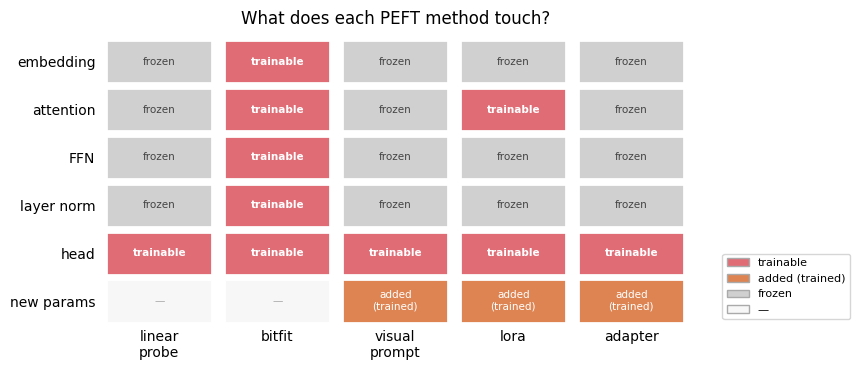

In [29]:
COMPONENTS = ["embedding", "attention", "FFN", "layer norm", "head", "new params"]

def component_status(model, model_name):
    status = {c: "frozen" for c in COMPONENTS}
    status["head"] = "trainable"

    for name, p in model.named_parameters():
        n = name.lower()
        if not p.requires_grad:
            continue
        if "embedding" in n or "cls_token" in n or "position" in n:
            status["embedding"] = "trainable"
        elif "attention" in n and "adapter" not in n:
            status["attention"] = "trainable"
        elif ("intermediate" in n or ("output" in n and "attention" not in n)) and "adapter" not in n:
            status["FFN"] = "trainable"
        elif "layernorm" in n or "norm" in n:
            status["layer norm"] = "trainable"

    if model_name in ("visual_prompt", "lora", "adapter"):
        status["new params"] = "added"
    else:
        status["new params"] = "none"
    return status

COLOR  = {"frozen": "#d0d0d0", "trainable": "#e06c75", "added": "#dd8452", "none": "#f7f7f7"}
LABEL  = {"frozen": "frozen",  "trainable": "trainable", "added": "added\n(trained)", "none": "—"}
TCOLOR = {"frozen": "#444",    "trainable": "white",     "added": "white",  "none": "#aaa"}

method_names = list(variants.keys())
grid = {m: component_status(variants[m], m) for m in method_names}

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.set_xlim(-0.5, len(method_names) - 0.5)
ax.set_ylim(-0.5, len(COMPONENTS) - 0.5)
ax.set_xticks(range(len(method_names)))
ax.set_xticklabels([m.replace("_", "\n") for m in method_names], fontsize=10)
ax.set_yticks(range(len(COMPONENTS)))
ax.set_yticklabels(COMPONENTS[::-1], fontsize=10)
ax.set_title("What does each PEFT method touch?", fontsize=12, pad=10)
ax.tick_params(length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

for xi, m in enumerate(method_names):
    for yi, comp in enumerate(COMPONENTS[::-1]):
        val = grid[m][comp]
        rect = plt.Rectangle((xi - 0.45, yi - 0.45), 0.9, 0.9,
                              fc=COLOR[val], ec="white", lw=2, zorder=2)
        ax.add_patch(rect)
        ax.text(xi, yi, LABEL[val], ha="center", va="center",
                fontsize=7.5, color=TCOLOR[val],
                fontweight="bold" if val == "trainable" else "normal", zorder=3)

from matplotlib.patches import Patch
legend_els = [Patch(fc=COLOR[k], ec="#aaa", label=LABEL[k].replace("\n", " "))
              for k in ["trainable", "added", "frozen", "none"]]
ax.legend(handles=legend_els, loc="lower right", fontsize=8,
          bbox_to_anchor=(1.28, 0), frameon=True)

plt.tight_layout()
plt.show()
